## DNN with SMOTEN


In [40]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from keras.models import Sequential
from keras.layers import Dense
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTEN

# Load customer data
customer_data = pd.read_csv('/content/Churn_Modelling.csv')

# Dropping ineffective columns
dataset = customer_data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
dataset.drop(dataset[dataset['CreditScore'] <= 359].index, inplace=True)
dataset.drop(dataset[dataset['Age'] >= 71].index, inplace=True)
dataset.drop(dataset[dataset['NumOfProducts'] >= 4].index, inplace=True)

# Define feature engineering functions
def product_utilization_rate_by_year(row):
    return row['NumOfProducts'] / (row['Tenure'] if row['Tenure'] > 0 else 1)

def product_utilization_rate_by_salary(row):
    return row['NumOfProducts'] / (row['EstimatedSalary'] if row['EstimatedSalary'] > 0 else 1)

def countries_monthly_average_salaries(row):
    return row['EstimatedSalary'] / 12

def feature_engineering(cus):
    df_fe = dataset.copy()
    df_fe['product_utilization_rate_by_year'] = df_fe.apply(lambda x: product_utilization_rate_by_year(x), axis=1)
    df_fe['product_utilization_rate_by_salary'] = df_fe.apply(lambda x: product_utilization_rate_by_salary(x), axis=1)
    df_fe['countries_monthly_average_salaries'] = df_fe.apply(lambda x: countries_monthly_average_salaries(x), axis=1)
    return df_fe

df_fe = feature_engineering(dataset)

# Converting inputs to numeric values
encoder = LabelEncoder()
df_fe["Geography"] = encoder.fit_transform(df_fe["Geography"])
df_fe["Gender"] = encoder.fit_transform(df_fe["Gender"])

# Encoding categorical data
df_fe = df_fe.drop(['Geography', 'Gender'], axis=1)
Geography = pd.get_dummies(dataset.Geography, drop_first=True)
Gender = pd.get_dummies(dataset.Gender).iloc[:, 0:]

df_fe = pd.concat([df_fe, Geography, Gender], axis=1)

# Data inputs
X = df_fe.drop(['Exited'], axis=1)

# Feature Scaling
sc = StandardScaler()
X = sc.fit_transform(X)
X = pd.DataFrame(X)

# Data outputs
Y = df_fe['Exited']

# Splitting the dataset into the Training set and Test set
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

# Handling class imbalance using SMOTE
sm = SMOTEN()
X_smot_train, Y_smot_train = sm.fit_resample(X_train, y_train)
X_smot_test, Y_smot_test = sm.fit_resample(X_test, y_test)

# Building the DNN model
model = Sequential()
model.add(Dense(10, activation='relu', input_shape=(X_smot_train.shape[1],)))  # Input layer
model.add(Dense(6, activation='relu'))  # Hidden layer 1
model.add(Dense(6, activation='relu'))  # Hidden layer 2
model.add(Dense(1, activation='sigmoid'))  # Output layer

# Compile the model with RMSProp
model.compile(optimizer='RMSprop', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_smot_train, Y_smot_train, epochs=9, batch_size=7, validation_split=0.2)

# Predict on test data
y_pred = model.predict(X_smot_test)
y_pred_classes = (y_pred > 0.5).astype(int)  # Convert probabilities to binary predictions

# Calculate accuracy
accuracy = accuracy_score(Y_smot_test, y_pred_classes)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Generate classification report
print(classification_report(Y_smot_test, y_pred_classes))

# Confusion matrix
conf_matrix = confusion_matrix(Y_smot_test, y_pred_classes)
print("Confusion Matrix:")
print(conf_matrix)

# Calculate AUC
auc = roc_auc_score(Y_smot_test, y_pred)
print(f'AUC: {auc:.2f}')


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/9
1430/1430 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.6627 - loss: 0.6187 - val_accuracy: 0.8018 - val_loss: 0.4467
Epoch 2/9
1430/1430 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7916 - loss: 0.4650 - val_accuracy: 0.8314 - val_loss: 0.3596
Epoch 3/9
1430/1430 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8172 - loss: 0.4246 - val_accuracy: 0.8470 - val_loss: 0.3409
Epoch 4/9
1430/1430 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8253 - loss: 0.4141 - val_accuracy: 0.9201 - val_loss: 0.1993
Epoch 5/9
1430/1430 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8384 - loss: 0.3896 - val_accuracy: 0.8897 - val_loss: 0.2334
Epoch 6/9
1430/1430 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8439 - loss: 0.3909 - val_accuracy: 0.9133 - val_loss: 0.2042
Epoch 7/9
1430/1430 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8483 - loss: 0.3683 - val_accuracy: 0.9041 - val_loss: 0.2123
Epoch 8/9
1430/1430 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8504 - loss: 0.3632 - val_ac

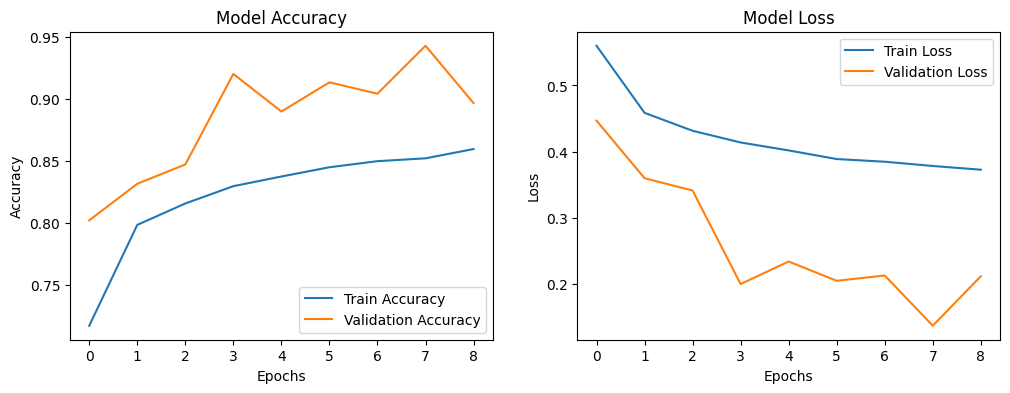

In [41]:

# Plotting history
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

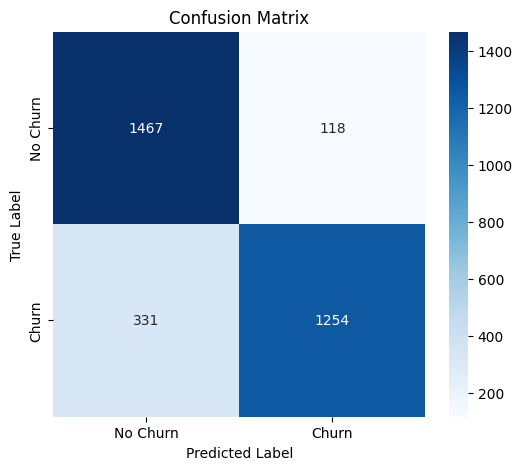

In [42]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

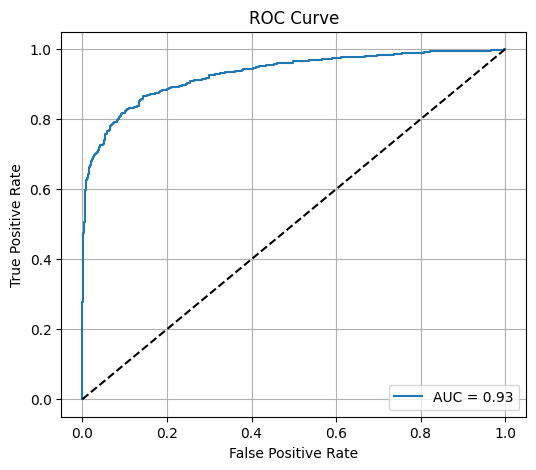

In [43]:
from sklearn.metrics import roc_curve

# محاسبه مقادیر برای رسم منحنی ROC
fpr, tpr, thresholds = roc_curve(Y_smot_test, y_pred)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # خط مرجع
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
